In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots, features
import pandas as pd
import yfinance as yf

sp500_components = dataset.SP500.load_historical()

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [3]:
ticker = "AAPL"
apple = yf.download(ticker, period="max", actions=True, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [4]:
plots.summarize_df(apple)

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 11427 entries, 1980-12-12 to 2026-04-16
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, AAPL)     11427 non-null  float64
 1   (Close, AAPL)         11427 non-null  float64
 2   (Dividends, AAPL)     11427 non-null  float64
 3   (High, AAPL)          11427 non-null  float64
 4   (Low, AAPL)           11427 non-null  float64
 5   (Open, AAPL)          11427 non-null  float64
 6   (Stock Splits, AAPL)  11427 non-null  float64
 7   (Volume, AAPL)        11427 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 803.5 KB
None


Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,11427.00000000,11427.00000000,11427.00000000,11427.00000000,11427.00000000,11427.00000000,11427.00000000,11427.00000000
mean,29.40119695,30.35252322,0.00088068,30.65845797,30.02046311,30.33098292,0.00148770,308071549.67716813
std,60.44516614,60.97664517,0.01314507,61.57803413,60.32122639,60.92719155,0.08207803,333008742.78799444
min,0.03760944,0.04910700,0.00000000,0.04966500,0.04910700,0.04966500,0.00000000,0.00000000
25%,0.24746595,0.30539100,0.00000000,0.31241050,0.29910699,0.30558051,0.00000000,105203400.00000000
50%,0.49719885,0.61160702,0.00000000,0.62410700,0.59821397,0.61035699,0.00000000,197114800.00000000
75%,21.98618507,24.62374973,0.00000000,24.84000015,24.38750076,24.62874985,0.00000000,388225600.00000000
max,285.92245483,286.19000244,0.26000000,288.61999512,283.29998779,286.20001221,7.00000000,7421640800.00000000


Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,,,
1980-12-12,0.09829751,0.12834799,0.00000000,0.12890600,0.12834799,0.12834799,0.00000000,469033600
1980-12-15,0.09316926,0.12165200,0.00000000,0.12221000,0.12165200,0.12221000,0.00000000,175884800
2026-04-15,266.42999268,266.42999268,0.00000000,266.55999756,257.80999756,258.16000366,0.00000000,49735000
2026-04-16,262.35998535,262.35998535,0.00000000,267.16000366,261.30999756,266.79998779,0.00000000,10533361


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [5]:
plots.YahooFinance.show_last_split(apple)

Price,Open,Adj Close,Dividends,Stock Splits
Date,,,,
2020-08-28,126.01249695,121.17151642,0.00000000,0.00000000
2020-08-31,127.58000183,125.28072357,0.00000000,4.00000000
2020-09-01,132.75999451,130.27095032,0.00000000,0.00000000


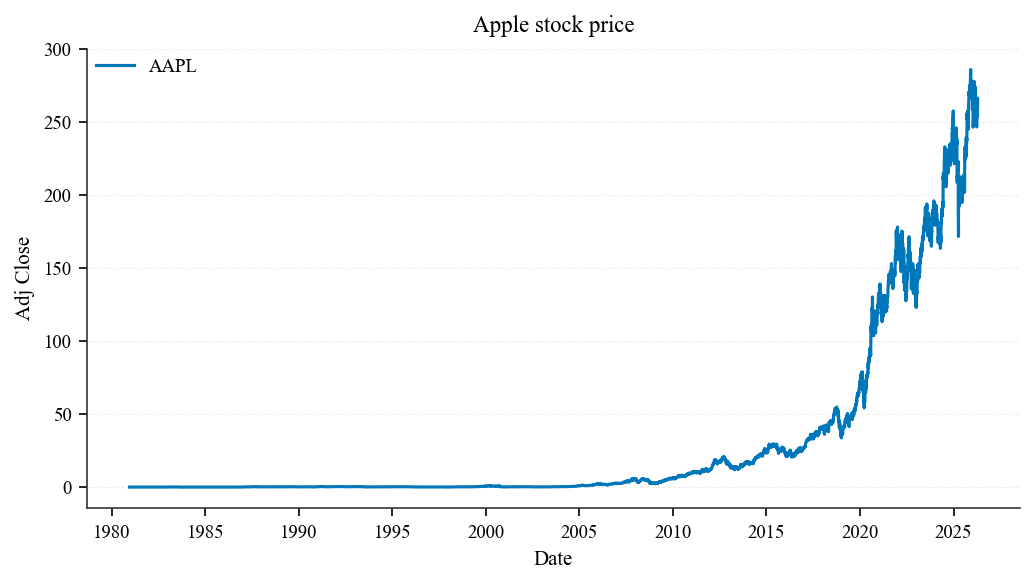

,AAPL
Date,
1980-12-12,0.09829751
1980-12-15,0.09316926
1980-12-16,0.08633081
1980-12-17,0.08846756
1980-12-18,0.09103252
...,...
2026-04-10,260.48001099
2026-04-13,259.20001221
2026-04-14,258.82998657


In [6]:
plots.YahooFinance.show_chart(apple, ticker, title="Apple stock price", hide_col=True)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [7]:
tickers = ["^GSPC", "^SP500TR", "CSPX.L", "^SP500EW", "RSP"]

dataset.YahooFinance.download(tickers)

SP500 = dataset.YahooFinance.load_ticker(tickers[0])
SP500TR = dataset.YahooFinance.load_ticker(tickers[1])
ETF = dataset.YahooFinance.load_ticker(tickers[2])

Saved Close.csv (24778 rows x 1199 columns)
Saved Open.csv (24778 rows x 1199 columns)
Saved High.csv (24778 rows x 1199 columns)
Saved Low.csv (24778 rows x 1199 columns)
Saved Volume.csv (24778 rows x 1199 columns)
Saved Adj_Close.csv (24778 rows x 1199 columns)
Saved Dividends.csv (24778 rows x 825 columns)
Saved Stock_Splits.csv (24778 rows x 825 columns)


Wyniki z kolumny Close i Adj Close są jednakowe.

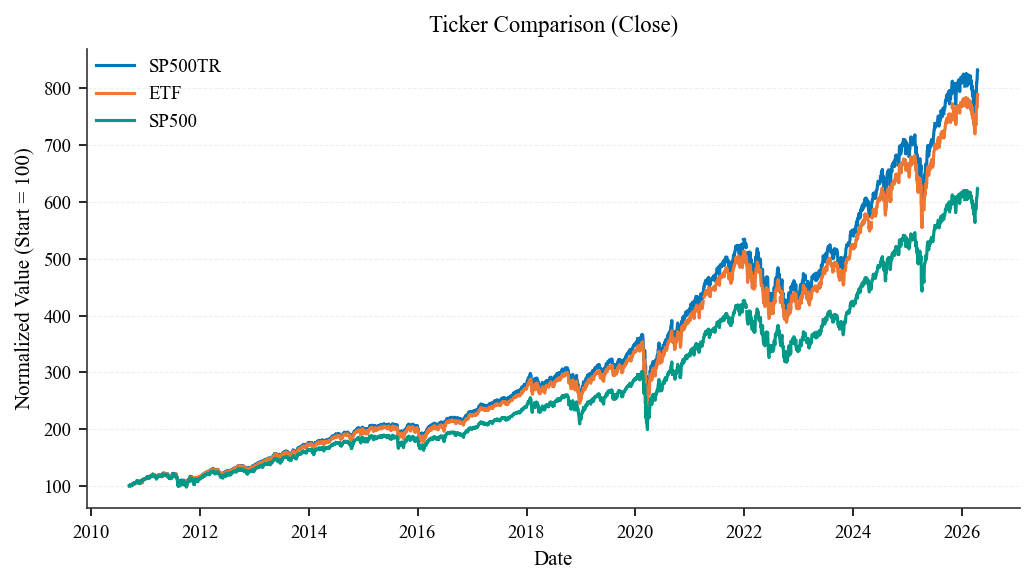

,SP500TR,ETF,SP500
Date,,,
2010-09-15,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,101.30748164
...,...,...,...
2026-04-10,808.69125779,768.28554794,605.90811791
2026-04-13,816.91836359,766.84112165,612.07218779
2026-04-14,826.56560106,781.49466977,619.28415258


In [8]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close")

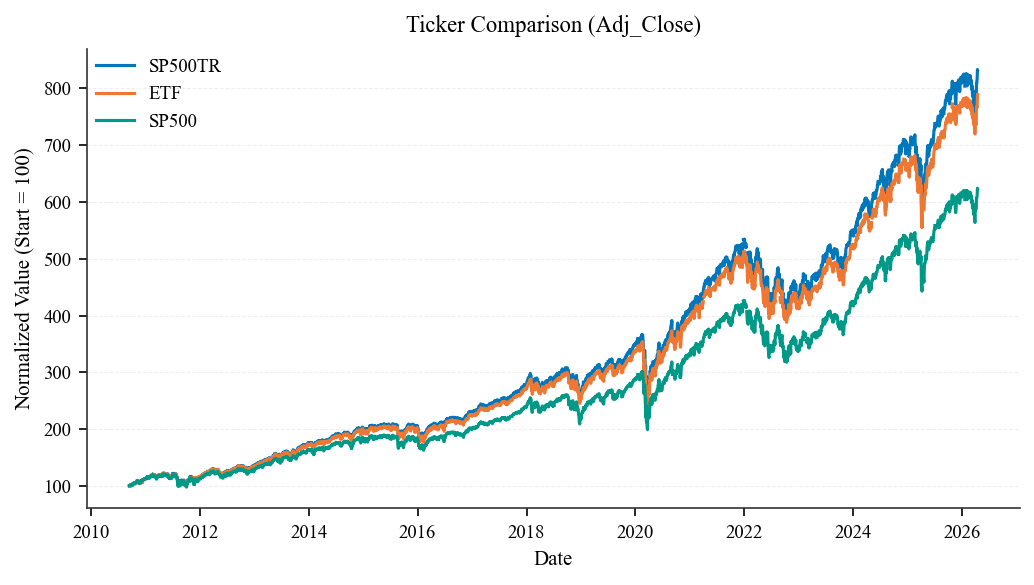

,SP500TR,ETF,SP500
Date,,,
2010-09-15,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,101.30748164
...,...,...,...
2026-04-10,808.69125779,768.28554794,605.90811791
2026-04-13,816.91836359,766.84112165,612.07218779
2026-04-14,826.56560106,781.49466977,619.28415258


In [9]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj_Close")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error). Sam ETF nie jest więc wystarczający jako pełny benchmark historyczny, ponieważ jego najdłuższa porównywalna historia (dla ETF-u akumulującego dywidendy) rozpoczyna się dopiero około 2010 roku. Z tego powodu w analizie potrzebne są oba szeregi: **SP500TR** (długi horyzont historyczny i referencja total return) oraz **benchmark hybrydowy** (odwzorowanie realnych warunków inwestora poprzez uwzględnienie tracking error i wykorzystanie rzeczywistych notowań ETF tam, gdzie są dostępne).

#### Hybrydowy indeks S&P 500

W praktyce: SP500TR odpowiada za część historyczną (przed debiutem ETF), a hybryda zapewnia ciągłość serii i porównywalność wyników z realnym instrumentem inwestycyjnym.

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Loading existing benchmark from /home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/data/processed/benchmark_2026-04-16.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24778 entries, 1927-12-30 00:00:00+00:00 to 2026-04-16 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         24689 non-null  float64
 1   Open          24689 non-null  float64
 2   High          24689 non-null  float64
 3   Low           24689 non-null  float64
 4   Volume        24689 non-null  float64
 5   Adj_Close     24689 non-null  float64
 6   Dividends     24689 non-null  float64
 7   Stock_Splits  24689 non-null  float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,24689.00000000,24689.00000000,24689.00000000,24689.00000000,24689.00000000,24689.00000000,24689.00000000,24689.00000000
mean,732.63011612,732.47819274,736.68649154,727.99783466,975227823.62639236,732.63011612,0.00000000,0.00000000
std,1258.15126055,1257.92545299,1264.58432799,1250.73839942,1692853441.95394349,1258.15126055,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,4.40000010,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,1610000.00000000,24.95999908,0.00000000,0.00000000
50%,103.63999939,103.63999939,104.48999786,102.80000305,22410000.00000000,103.63999939,0.00000000,0.00000000
75%,1094.02001953,1094.13000488,1100.08996582,1085.43005371,1190300000.00000000,1094.02001953,0.00000000,0.00000000
max,7022.95019531,7037.77978516,7040.02978516,7008.52001953,11456230000.00000000,7022.95019531,0.00000000,0.00000000


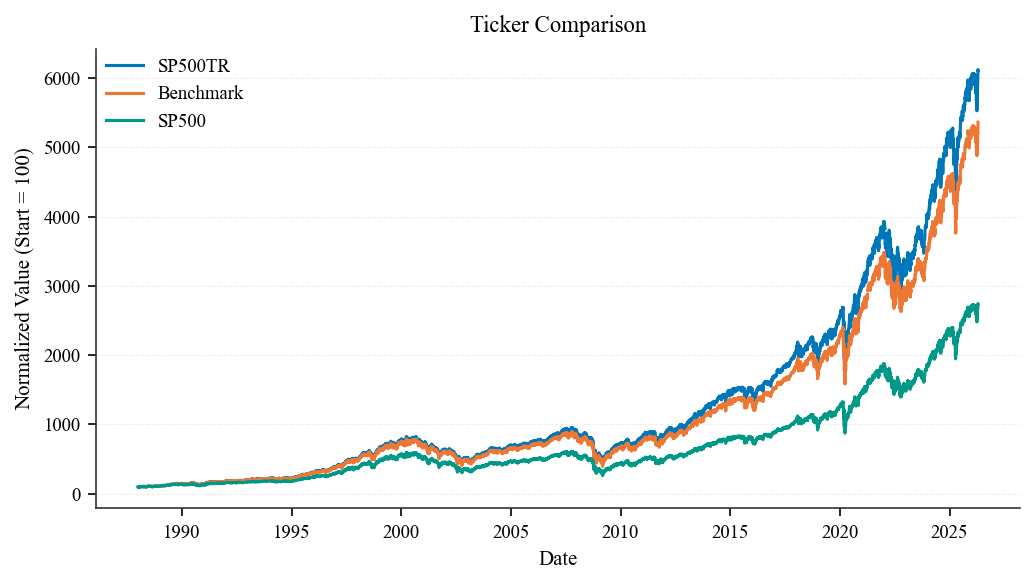

,SP500TR,Benchmark,SP500
Date,,,
1988-01-04,100.00000000,100.00000000,100.00000000
1988-01-05,101.07413488,101.07277291,101.05102853
1988-01-06,101.17569326,101.17296661,101.15261865
1988-01-07,102.02718642,102.02306204,102.00437791
1988-01-08,95.12929205,95.12416470,95.10041087
...,...,...,...
2026-04-10,5940.70015447,5206.46300797,2663.47193549
2026-04-13,6001.13702479,5196.67452240,2690.56816781
2026-04-14,6072.00627755,5295.97764789,2722.27077297


In [10]:
benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True)

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

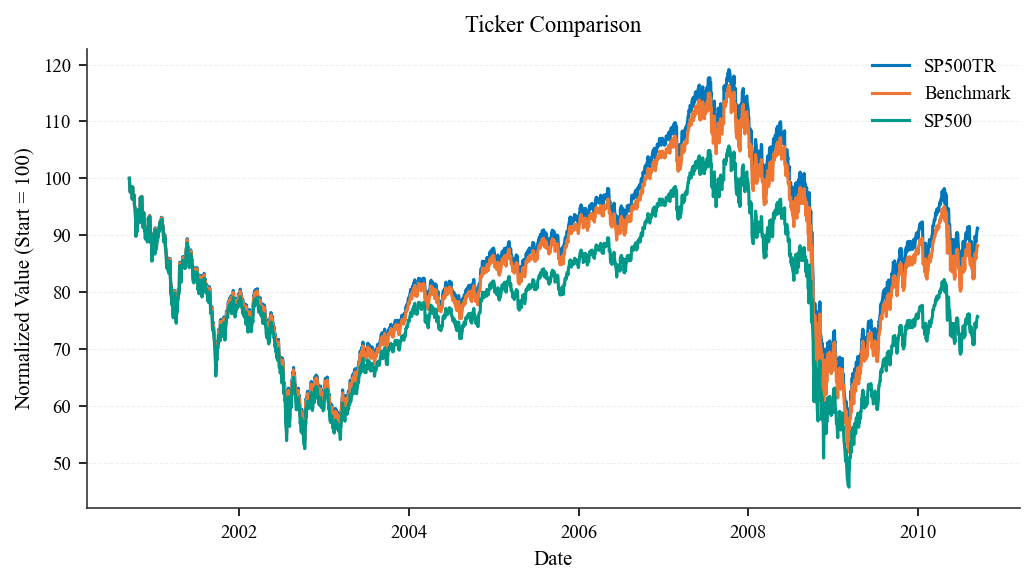

,SP500TR,Benchmark,SP500
Date,,,
2000-09-14,100.00000000,100.00000000,100.00000000
2000-09-15,98.98306332,98.98172952,98.98303453
2000-09-18,97.54650677,97.54387792,97.54468755
2000-09-19,98.58632187,98.58233658,98.58394250
2000-09-20,98.01042757,98.00514493,98.00589995
...,...,...,...
2010-09-08,89.38764760,86.41606537,74.20435276
2010-09-09,89.81993082,86.83280778,74.56292972
2010-09-10,90.25854274,87.25565709,74.92555407


In [11]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "SP500": SP500
}, hide_col=True, start_date="2000-09-14", end_date="2010-09-14")

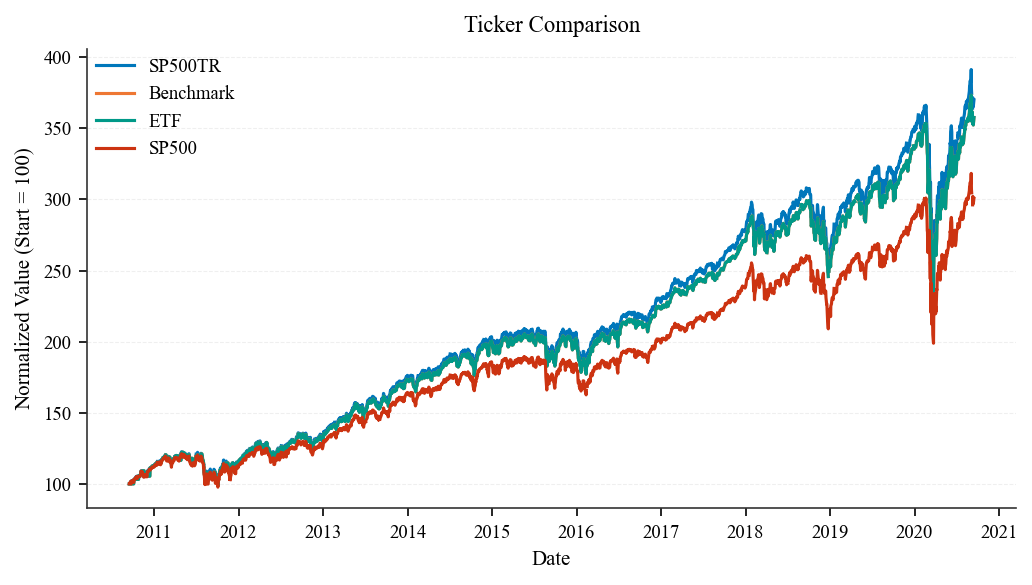

,SP500TR,Benchmark,ETF,SP500
Date,,,,
2010-09-15,100.00000000,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,100.00000000,101.30748164
...,...,...,...,...
2020-09-08,364.13432784,353.10862688,353.10862688,296.14515070
2020-09-09,371.48993491,357.72449837,357.72449837,302.11099071
2020-09-10,364.97495752,357.89197132,357.89197132,296.79843039


In [12]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "ETF": ETF,
    "SP500": SP500
}, hide_col=True, start_date="2010-09-14", end_date="2020-09-14")

#### S&P 500 Equal Weighted

Dla indeksu S&P 500 Equal Weighted dostępne są następujące tickery:

- **SP500EW (^SP500EW, S&P 500 Equal Weight Index)** – indeks cenowy (*price return*) równoważonej wersji S&P 500, gdzie każda spółka ma identyczny udział niezależnie od kapitalizacji
- **ETF_EW (RSP, Invesco S&P 500 Equal Weight ETF)** – fundusz ETF replikujący indeks S&P 500 z równymi wagami, akumulujący dywidendy

Na wykresie widać, że w ostatnich latach benchmark oparty na S&P 500 przewyższał ETF na S&P 500 Equal Weight. Jednak w latach przed 2018 strategia równych wag często osiągała podobne lub lepsze wyniki. Oznacza to, że relatywna efektywność podejścia equal-weight w dużej mierze zależy od siły największych spółek w indeksie.

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24778 entries, 1927-12-30 00:00:00+00:00 to 2026-04-16 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         4853 non-null   float64
 1   Open          4853 non-null   float64
 2   High          4853 non-null   float64
 3   Low           4853 non-null   float64
 4   Volume        4853 non-null   float64
 5   Adj_Close     4853 non-null   float64
 6   Dividends     4853 non-null   float64
 7   Stock_Splits  4853 non-null   float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,4853.00000000,4853.00000000,4853.00000000,4853.00000000,4853.00000000,4853.00000000,4853.00000000,4853.00000000
mean,3806.66595600,3805.38382254,3829.23050345,3780.95576766,0.78302081,3806.66595600,0.00000000,0.00000000
std,1923.31114900,1922.48474222,1932.92416975,1912.84850219,54.54795216,1923.31114900,0.00000000,0.00000000
min,824.01000977,824.01000977,849.15997314,810.59997559,0.00000000,824.01000977,0.00000000,0.00000000
25%,2026.35998535,2026.02001953,2036.20996094,2013.54003906,0.00000000,2026.35998535,0.00000000,0.00000000
50%,3344.63989258,3343.55004883,3354.90991211,3328.32006836,0.00000000,3344.63989258,0.00000000,0.00000000
75%,5608.93017578,5607.91992188,5676.12988281,5566.58007812,0.00000000,5608.93017578,0.00000000,0.00000000
max,8290.63964844,8289.28027344,8306.87988281,8219.33984375,3800.00000000,8290.63964844,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24778 entries, 1927-12-30 00:00:00+00:00 to 2026-04-16 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         5777 non-null   float64
 1   Open          5777 non-null   float64
 2   High          5777 non-null   float64
 3   Low           5777 non-null   float64
 4   Volume        5777 non-null   float64
 5   Adj_Close     5777 non-null   float64
 6   Dividends     5777 non-null   float64
 7   Stock_Splits  5777 non-null   float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,5777.00000000,5777.00000000,5777.00000000,5777.00000000,5777.00000000,5777.00000000,5777.00000000,5777.00000000
mean,85.11769649,85.11569804,85.58323521,84.58833569,2083766.52189718,74.84854388,0.00540505,0.00069240
std,48.09390365,48.08812447,48.32767153,47.84429266,3724193.27455876,49.64361500,0.05079714,0.05262702
min,20.59000015,20.59000015,21.15999985,18.00000000,4400.00000000,15.51315212,0.00000000,0.00000000
25%,43.75999832,43.79999924,44.07249832,43.48749924,398000.00000000,32.69854736,0.00000000,0.00000000
50%,75.73000336,75.66999817,76.05999756,75.16000366,782400.00000000,62.63351822,0.00000000,0.00000000
75%,112.08000183,112.12999725,112.69000244,111.41000366,1987600.00000000,101.09176636,0.00000000,0.00000000
max,204.97000122,204.27000427,205.24000549,203.17999268,57508500.00000000,204.09623718,0.83100000,4.00000000


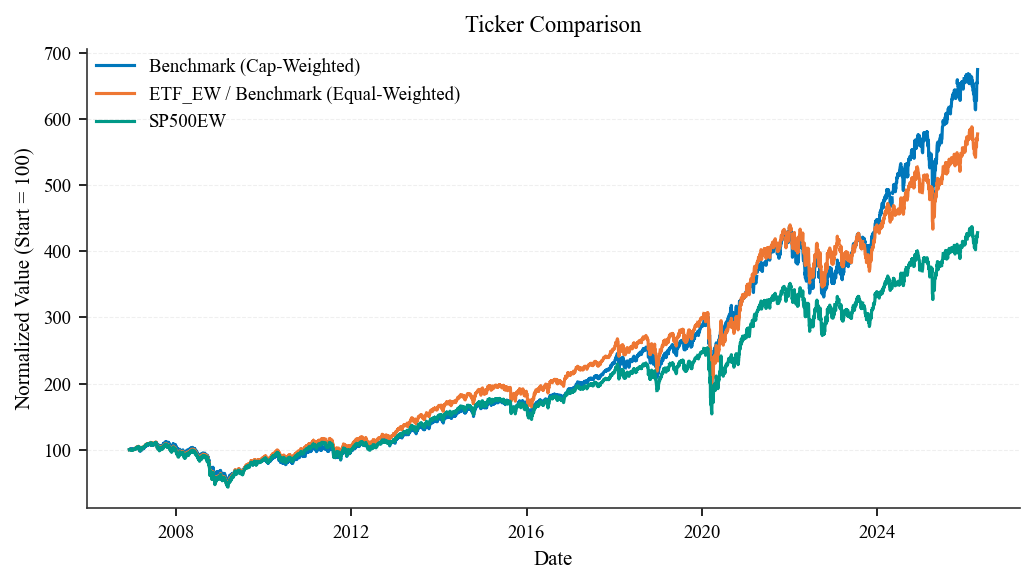

,Benchmark (Cap-Weighted),ETF_EW / Benchmark (Equal-Weighted),SP500EW
Date,,,
2006-12-08,100.00000000,100.00000000,100.00000000
2006-12-11,100.22713060,100.04207389,100.08383243
2006-12-12,100.12351959,99.89505153,99.87873422
2006-12-13,100.25759370,100.06300644,99.92091110
2006-12-14,101.13466029,100.79785448,100.74660099
...,...,...,...
2026-04-10,654.85402686,566.44938931,420.13602801
2026-04-13,653.62285914,572.72889199,424.98840989
2026-04-14,666.11292226,575.11970839,426.64822117


In [13]:
SP500EW = dataset.YahooFinance.load_ticker(tickers[3])
ETF_EW = dataset.YahooFinance.load_ticker(tickers[4])

plots.summarize_df(SP500EW)
plots.summarize_df(ETF_EW)

plots.YahooFinance.compare_tickers({
    "Benchmark (Cap-Weighted)": benchmark,
    "ETF_EW / Benchmark (Equal-Weighted)": ETF_EW,
    "SP500EW": SP500EW,
}, hide_col=True)

Analogicznie do hybrydowego benchmarku dla S&P 500 ważonego kapitalizacją, można byłoby
skonstruować benchmark hybrydowy dla wersji equal-weighted, uwzględniając wpływ dywidend
zamiast błędu odwzorowania. W tym przypadku jednak `ETF_EW` (RSP) dysponuje najdłuższą
dostępną historią — sięgającą 2003 roku — a przedłużenie jej wstecz napotyka na istotne
ograniczenia: indeks dochodowy `SP500EWTR` nie jest dostępny w serwisie Yahoo Finance,
`SP500EW` obejmuje krótszy okres, natomiast zastosowanie benchmarku cap-weighted jako
substytutu zniekształciłoby charakterystykę strategii equal-weighted. Z tego powodu
`benchmark_ew` ograniczony jest do okresu dostępności `ETF_EW`, a porównanie obu podejść
prowadzone jest na wspólnym horyzoncie czasowym.

In [14]:
benchmark_ew = SP500EW

#### Uzyskanie danych pojedyńczych spółek

In [15]:
tickers = dataset.SP500.extract_tickers(sp500_components)

dataset.YahooFinance.download(tickers)
yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.load()
for column_name, frame in yf_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

Number of unique tickers extracted: 1194


$BNI: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$ANDW: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$BRL: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$BXLT: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$ARG: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$BGG: possibly delisted; no timezone found
$BIG: possibly delisted; no timezone found
$AABA: possibly delisted; no timezone found
$AAMRQ: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$APCC: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$BLS: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
BFI: Period 'max' is invalid, must be one of: 1d, 5d
$AHM: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found
$ARC: possibly delisted; no timezone found
$ABKFQ: possibly delisted; no timezone found
$AKS: possibly delisted; no t

$CTLT: possibly delisted; no timezone found
$CHK: possibly delisted; no timezone found
$ETFC: possibly delisted; no timezone found
$CTXS: possibly delisted; no timezone found
$CEN: possibly delisted; no timezone found
$DI: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$CEPH: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$CITGQ: possibly delisted; no timezone found
$CXO: possibly delisted; no timezone found
$CFL: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$EOP: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$CGP: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$DISCA: possibly delisted; no timezone found
$DWDP: possibly delisted; no timezone found
$CIT.A: possibly delisted; no timezone found
$CFN: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$EDS: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$CMA: possibly delisted; no 

$JHF: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$HCBK: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$FTL.A: possibly delisted; no timezone found
$GIDL: possibly delisted; no timezone found
$GFS.A: possibly delisted; no timezone found
$HDLM: possibly delisted; no timezone found
$HI: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16) (Yahoo error = "No data found, symbol may be delisted")
$FLMIQ: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$FSL: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$GGP: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$HPH: possibly delisted; no timezone found
$HMA: possibly delisted; no timezone found
$GAS: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$FDC: possibly delisted; no timezone found
$IGT: possibly delisted; no timezone found
$FBHS: possibly delisted; no timezone found
$HFS: possibly d

$NYN: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$MIL: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$MJN: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$MWW: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$LM: possibly delisted; no timezone found
$MZIAQ: possibly delisted; no timezone found
$NLSN: possibly delisted; no timezone found
$NLC: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$NAE: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$MTLQQ: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$LLL: possibly delisted; no timezone found
$NAV: possibly delisted; no timezone found
$NBL: possibly delisted; no timezone found
$NVLS: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$MMC: possibly delisted; no timezone found
$NLOK: possibly delisted; no timezone found
$KORS: possibly delisted; no price data fo

$PGN: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$SOV: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$RNB: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$QTRN: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$SEBL: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$PX: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16) (Yahoo error = "No data found, symbol may be delisted")
$SMS: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$RAD: possibly delisted; no timezone found
$RE: possibly delisted; no timezone found
$RBD: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
PET: Period 'max' is invalid, must be one of: 1d, 5d
$SFS: possibly delisted; no timezone found
$PDCO: possibly delisted; no timezone found
$SAI: possibly delisted; no timezone found
$PSFT: possibly delisted; no timezone found
$PXD: possibly delisted

$SUNEQ: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$WYND: possibly delisted; no timezone found
$XLNX: possibly delisted; no timezone found
$VAR: possibly delisted; no timezone found
$TWC: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$WFM: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$SXCL: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$WLP: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$WYE: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$UPR: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$TMK: possibly delisted; no timezone found
$UTX: possibly delisted; no timezone found
$WLTW: possibly delisted; no timezone found
$SYMC: possibly delisted; no timezone found
$TIF: possibly delisted; no timezone found
$USS: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$USHC: possibly delisted; no timezone fou

Saved Close.csv (24778 rows x 1199 columns)
Saved Open.csv (24778 rows x 1199 columns)
Saved High.csv (24778 rows x 1199 columns)
Saved Low.csv (24778 rows x 1199 columns)
Saved Volume.csv (24778 rows x 1199 columns)
Saved Adj_Close.csv (24778 rows x 1199 columns)
Saved Dividends.csv (24778 rows x 825 columns)
Saved Stock_Splits.csv (24778 rows x 825 columns)
Close: (24778, 1199), 1927-12-30 -> 2026-04-16
Open: (24778, 1199), 1927-12-30 -> 2026-04-16
High: (24778, 1199), 1927-12-30 -> 2026-04-16
Low: (24778, 1199), 1927-12-30 -> 2026-04-16
Volume: (24778, 1199), 1927-12-30 -> 2026-04-16
Adj_Close: (24778, 1199), 1927-12-30 -> 2026-04-16
Dividends: (24778, 825), 1927-12-30 -> 2026-04-16
Stock_Splits: (24778, 825), 1927-12-30 -> 2026-04-16


#### Ile danych brakuje?

Na poniższym wykresie widać, że w 1996 dane z Yahoo Finance pokrywają tylko 38%. Przy wyższym pokryciu można byłoby zastosować imputację brakujących danych, jednak jest ono na tyle małe, że konieczne będzie skorzystanie z dostawców danych, pokrywających spółki, które już nie są notowane.

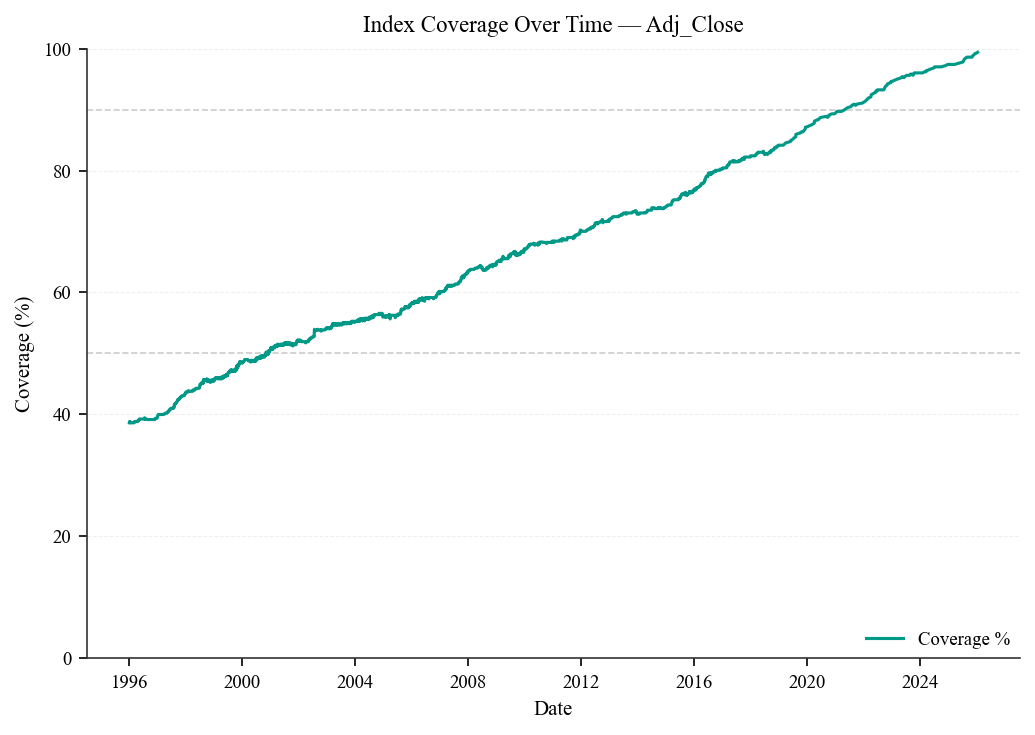

Missing ticker coverage periods:
- AABA:
  missing from 1999-12-08 to 2017-06-16
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABC:
  missing from 2001-08-30 to 2023-08-25
- ABI:
  missing from 1996-01-02 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABMD:
  missing from 2018-05-31 to 2022-12-19
- ABS:
  missing from 1996-01-02 to 2006-05-31
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACAS:
  missing from 2007-07-09 to 2009-03-02
- ACKH:
  missing from 1996-01-02 to 2000-11-08
- ACS:
  missing from 2004-04-02 to 2010-02-02
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2007-06-26
- ADS:
  missing from 2013-12-23 to 2020-05-22
- ADT:
  missing from 2012-10-02 to 2016-04-28
- AEE:
  missing from 1996-01-02 to 1997-12-31
- AET:
  missing from 1996-01-02 to 2018-11-28
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-08-20
- AGN:
  missing

,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,312.50055453,184.24879852,0.00000000,496.74935305,62.77348877
std,72.76614649,67.95654165,0.00000000,5.16624733,14.02972198
min,188.00000000,3.00000000,0.00000000,487.00000000,38.60369610
25%,255.00000000,133.00000000,0.00000000,494.00000000,51.51515152
50%,313.00000000,184.00000000,0.00000000,497.00000000,62.97786720
75%,364.00000000,240.00000000,0.00000000,499.00000000,73.23943662
max,500.00000000,299.00000000,0.00000000,507.00000000,99.40357853


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,188,299,0,487,38.60369610
1996-01-03,189,298,0,487,38.80903491
2025-12-22,499,4,0,503,99.20477137
2026-01-14,500,3,0,503,99.40357853


In [ ]:
coverage_df = plots.coverage_over_time(yf_data, sp500_components)
plots.summarize_df(coverage_df)

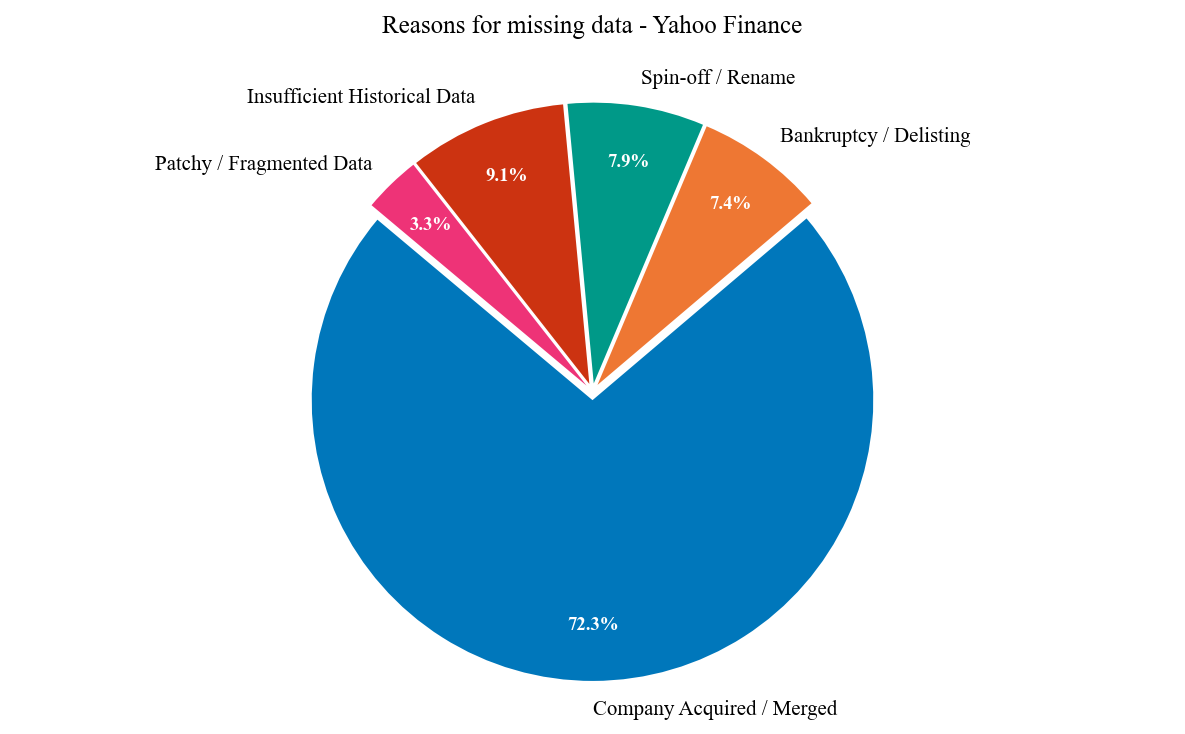

In [ ]:
plots.plot_missing_data_reasons("Yahoo Finance")